# Project 1 — Regression, resampling methods and gradient descent

**FYS-STK3155/4155**, University of Oslo, autumn 2026
**Parisa Amin**

We study polynomial regression on Runge's function

$$f(x) = \frac{1}{1+25x^2}, \qquad x \in [-1, 1],$$

with ordinary least squares, Ridge and Lasso; the bootstrap and $k$-fold
cross-validation; and gradient-descent optimisers.

Reusable functions live in `regression.py`; this notebook runs the experiments.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# pick up edits to regression.py without restarting the kernel
%load_ext autoreload
%autoreload 2

from regression import (runge, make_data, polynomial_features, MSE, R2, ols, fit_predict,
                        BLUE, RED, YELLOW, GREY, GREEN)

np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

---
# Part a) Ordinary Least Squares

**Goal:** build the machinery, and see overfitting happen — training MSE falling
for ever while test MSE turns back up, driven by coefficients that explode.

## a.1 The data

Generate Runge data on $[-1,1]$ with noise $\varepsilon\sim\mathcal{N}(0,\sigma^2)$,
$\sigma = 0.1$. Plot the noisy samples against the true function to check it looks right.

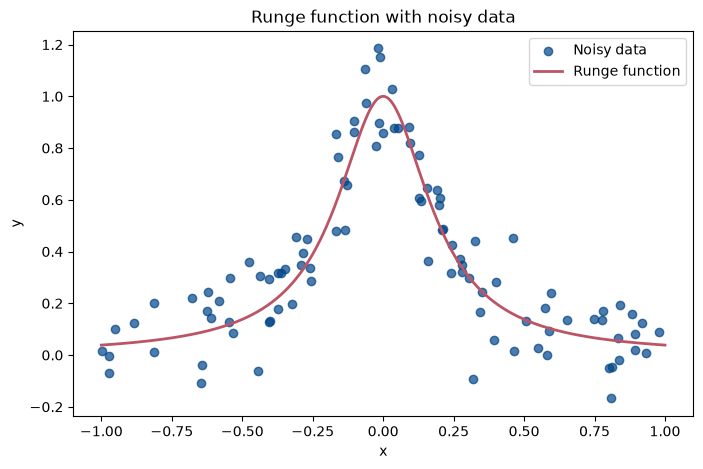

In [2]:
x , y= make_data(n= 100 , sigma= 0.1 , seed= 2026)
x_fine = np.linspace(-1,1, 1000)
y_fine = runge(x_fine)


plt.figure(figsize=(8,5))
plt.scatter(x,y, label= "Noisy data" , color= BLUE , alpha= 0.7)
plt.plot(x_fine , y_fine , label= "Runge function" , color= RED , linewidth= 2)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Runge function with noisy data")
plt.legend()

plt.show()


## a.2 Train/test split and scaling

Split roughly 80/20. Then **centre `y` and standardise the feature columns —
fitting the scaler on the training data only**, and applying those same numbers to
the test data.

Why it matters: if the scaler sees the test set, information has leaked from test
into train and your error estimate is optimistically biased. The project asks for a
critical discussion of this, so write down what you did and why.

In [3]:
from sklearn.model_selection import train_test_split

x_train , x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2 , random_state= 2026)

print(len(x_test))
print(len(x_train))


20
80


## a.3 MSE and $R^2$ against polynomial degree

For degree $= 1 \ldots 15$: build the design matrix, fit OLS, record training and
test MSE and $R^2$.

Expect: training MSE falls monotonically; test MSE falls then rises. Use a log
scale on the MSE axis and mark the noise floor $\sigma^2$ with a grey dashed line —
no model can do better than that.

In [4]:
print(x_train.shape)
print(x_train.ndim)

(80,)
1


In [5]:

# x = raw input vector, X = polynomial design matrix
degrees = np.arange(1, 16)

#print(degrees)

mse_train= np.zeros(len(degrees))
mse_test= np.zeros(len(degrees))

r2_train= np.zeros(len(degrees))
r2_test= np.zeros(len(degrees))

for i, degree in enumerate(degrees):

    X_train= polynomial_features(x_train, degree)
    X_test= polynomial_features(x_test, degree)

    X_mean= np.mean(X_train, axis=0)  #capital X
    X_std= np.std(X_train, axis=0)    #capital X

    X_train_scaled= (X_train - X_mean)/X_std
    X_test_scaled= (X_test - X_mean)/ X_std

    y_mean= np.mean(y_train)
    y_train_centered= y_train - y_mean

    theta= ols(X_train_scaled, y_train_centered)

    y_train_pred = X_train_scaled @ theta + y_mean
    y_test_pred = X_test_scaled @ theta + y_mean


    mse_train[i]= MSE(y_train, y_train_pred)
    mse_test[i]= MSE(y_test, y_test_pred)

    r2_train[i]= R2(y_train, y_train_pred)
    r2_test[i]= R2(y_test, y_test_pred) 

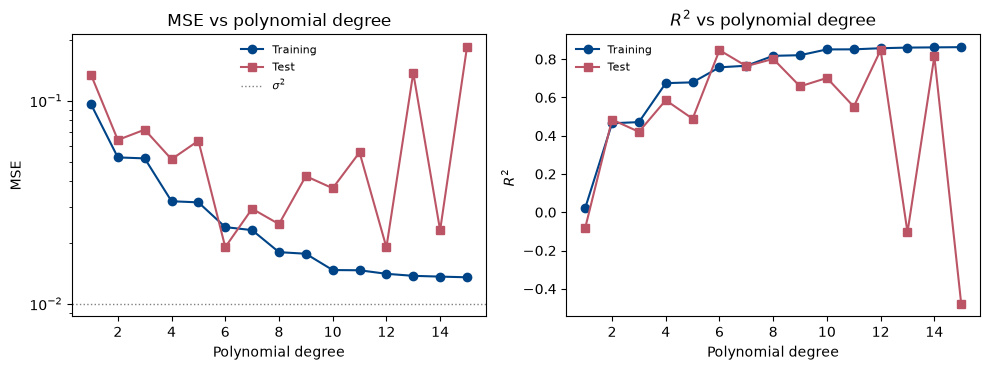

In [6]:
plt.figure(figsize=(10, 3.8))

#MSE plot
plt.subplot(1, 2, 1)

plt.plot(degrees, mse_train,"o-", color=BLUE, label="Training")
plt.plot(degrees, mse_test, "s-",color=RED, label="Test")

plt.yscale("log")                                      # MSE panel only
plt.axhline(0.1**2, color="gray", ls=":", lw=1, label=r"$\sigma^2$")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.title("MSE vs polynomial degree")
plt.legend(frameon=False, fontsize=8)

#R2 plot
plt.subplot(1, 2, 2)

plt.plot(degrees, r2_train,"o-", color=BLUE, label="Training")
plt.plot(degrees, r2_test,"s-", color=RED, label="Test")

plt.xlabel("Polynomial degree")
plt.ylabel( r"$R^2$ " )
plt.title( r"$R^2$ vs polynomial degree")
plt.legend(frameon=False, fontsize=8)


plt.tight_layout()
plt.savefig("../results/a3_mse_r2.pdf", bbox_inches="tight")
plt.show()


## a.4 The coefficients $\theta$ against degree

This is the figure that explains the U-shape. Plot the magnitude of the fitted
coefficients as the degree grows — expect them to reach enormous values with
alternating signs, because the design matrix becomes nearly singular and the fit
relies on huge cancelling terms.

A log scale on $|\theta_j|$ makes it readable.

In [7]:
 # a.4 — how the coefficients grow with degree

theta_all = []
max_theta = np.zeros(len(degrees))

for i, degree in enumerate(degrees):

    X_train= polynomial_features(x_train, degree)

    X_mean= np.mean(X_train, axis=0)
    X_std = np.std(X_train, axis=0)

    X_train_scaled= (X_train - X_mean) / X_std

    y_mean= np.mean(y_train)
    y_train_centered= y_train - y_mean

    theta = ols(X_train_scaled, y_train_centered)
    theta_all.append(theta)

    max_theta[i] = np.max(np.abs(theta))



In [8]:
#print(max_theta)
print(theta_all[5])

print(max_theta[5])

[-0.0534 -1.3045  0.0159  2.1179  0.0137 -1.0449]
2.1178573485608494


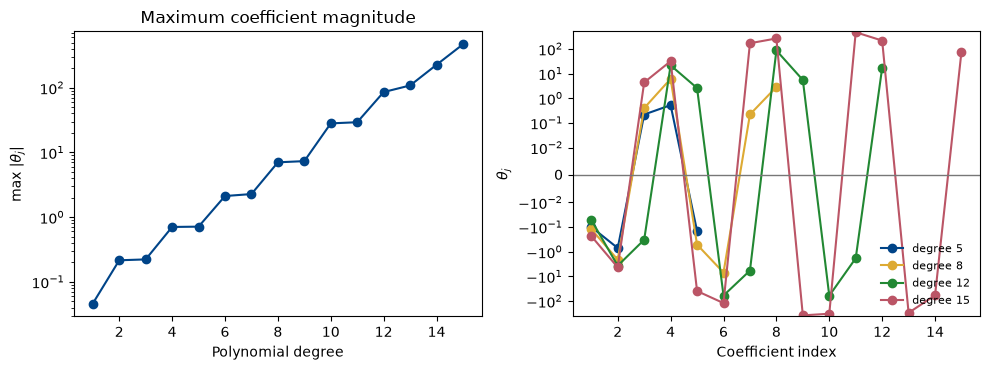

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))


##Left panel

axes[0].semilogy(degrees, max_theta, "o-", color=BLUE )

axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel(r"max $|\theta_j|$")
axes[0].set_title("Maximum coefficient magnitude")


## Right panel
for degree, c in zip([5, 8, 12, 15], [BLUE, YELLOW, GREEN, RED]):
    theta = theta_all[degree - 1]
    j = np.arange(1, degree + 1)
    axes[1].plot(j, theta, "o-", color=c, label=f"degree {degree}")



axes[1].axhline(0, color=GREY, linewidth=1)
axes[1].set_yscale("symlog", linthresh=1e-2)
axes[1].set_xlabel("Coefficient index")
axes[1].set_ylabel(r"$\theta_j$")
axes[1].legend(frameon= False, fontsize=8)

plt.tight_layout()
plt.savefig("../results/a4_theta.pdf", bbox_inches="tight")
plt.show()




## a.5 Dependence on the number of points and the noise level

Repeat the degree sweep for a few values of $n$ and of $\sigma$.

Expect: more data supports a higher degree before overfitting sets in; more noise
pushes the optimal degree down.

In [10]:
# Different number of points
degrees = np.arange(1, 16)
n_values = [50, 100, 200, 1000]
sigma_fixed= 0.1

mse_by_n= {}


for n in n_values:

    #Generate new data set
    x_n , y_n = make_data(n=n, sigma=sigma_fixed, seed=2026)

    #split and test
    x_train_n, x_test_n, y_train_n , y_test_n = train_test_split(x_n, y_n, test_size= 0.2, random_state=2026)

     # One MSE value for each degree
    mse_test_n = np.zeros(len(degrees))

    for i , degree in enumerate(degrees):
        y_train_pred , y_test_pred , theta = fit_predict(x_train_n, x_test_n, y_train_n, degree)

        mse_test_n[i] = MSE(y_test_n, y_test_pred)


    mse_by_n[n] = mse_test_n



In [11]:
sigma_values = [0.01, 0.1, 0.3]
n_fixed = 100

mse_by_sigma = {}

for sigma in sigma_values:
    #Generate new data set
    x_s , y_s = make_data(n=n_fixed, sigma=sigma, seed=2026)

    #split and test
    x_train_s, x_test_s, y_train_s , y_test_s = train_test_split(x_s, y_s, test_size= 0.2, random_state=2026)


    # Store test MSE for all degrees
    mse_test_s = np.zeros(len(degrees))

    for i , degree in enumerate(degrees):
        y_train_pred , y_test_pred , theta = fit_predict(x_train_s, x_test_s, y_train_s, degree)

        mse_test_s[i] = MSE(y_test_s, y_test_pred)


    mse_by_sigma[sigma] = mse_test_s

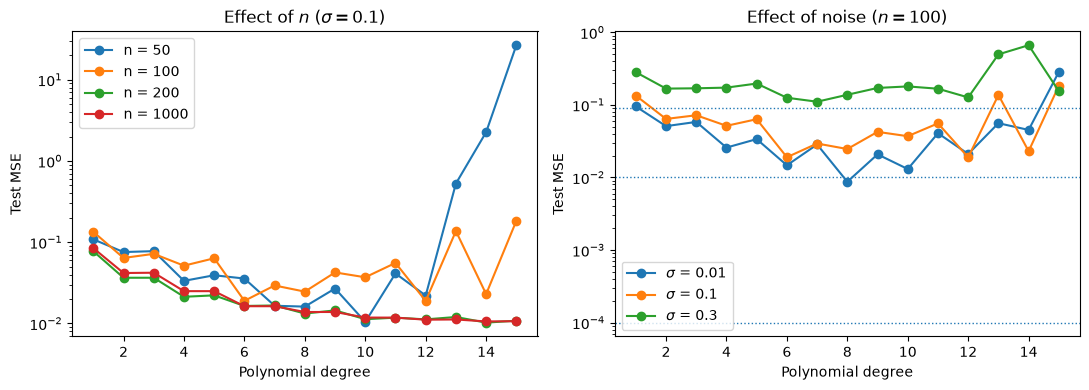

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))


# --------------------------------------------------
# Left panel: different n
# --------------------------------------------------

for n in n_values:

    axes[0].semilogy(
        degrees,
        mse_by_n[n],
        "o-",
        label=f"n = {n}"
    )

axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("Test MSE")
axes[0].set_title(r"Effect of $n$ ($\sigma=0.1$)")
axes[0].legend()


# --------------------------------------------------
# Right panel: different sigma
# --------------------------------------------------

for sigma in sigma_values:

    axes[1].semilogy(
        degrees,
        mse_by_sigma[sigma],
        "o-",
        label=fr"$\sigma$ = {sigma}"
    )

    # Noise variance reference
    axes[1].axhline(
        sigma**2,
        linestyle=":",
        linewidth=1
    )

axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel("Test MSE")
axes[1].set_title(r"Effect of noise ($n=100$)")
axes[1].legend()


plt.tight_layout()

plt.savefig(
    "../results/a5_n_sigma.pdf",
    bbox_inches="tight"
)

plt.show()

---
# Part b) Ridge regression

**Goal:** control the explosion. Ridge minimises

$$C(\theta) = \frac{1}{n}\lVert X\theta - y \rVert^2 + \lambda\lVert\theta\rVert^2,
\qquad
\theta = (X^TX + n\lambda I)^{-1}X^Ty.$$

**The factor $n$ comes from the $1/n$ in the cost function — don't drop it.**

## b.1 Implement Ridge, and benchmark it

Add `ridge(X, y, lam)` to `regression.py`, then check it two ways:

1. `lam = 0` must reproduce your OLS result exactly
2. it must match `Ridge(alpha=n*lam, fit_intercept=False)` from scikit-learn

These benchmarks belong in the report — the course guidelines call validation
against known results *"extremely important"*.

In [ ]:
from sklearn.linear_model import Ridge

# TODO: benchmark your ridge() against sklearn, print max |ours - sklearn|


## b.2 MSE against degree, for several $\lambda$

Try `lambdas = np.logspace(-8, 2, 11)`. Expect the U to grow shallower and move to
the right as $\lambda$ increases.

In [ ]:
# TODO


## b.3 MSE against $\lambda$, at fixed high degree

Fix a degree where OLS clearly overfits (say 15) and sweep $\lambda$ on a log axis.
Expect a U: too little $\lambda$ overfits, too much underfits.

In [ ]:
# TODO


## b.4 Coefficient paths

Plot $\theta_j$ against $\lambda$ (log axis). Watch every coefficient shrink smoothly
toward zero — but **never reach it exactly**. That is the difference from Lasso in
part g).

In [ ]:
# TODO


## b.5 The SVD picture

With $X = U\Sigma V^T$, the two estimators differ only by a factor on each singular
direction:

| | coefficient on direction $j$ |
|---|---|
| OLS | $\dfrac{1}{\sigma_j}(u_j^Ty)$ |
| Ridge | $\dfrac{\sigma_j}{\sigma_j^2+\lambda}(u_j^Ty)$ |

so Ridge applies the shrinkage factor $\sigma_j^2/(\sigma_j^2+\lambda)$: directions with
large $\sigma_j$ pass through untouched, directions with small $\sigma_j$ are crushed.

Compute the singular values of your degree-15 design matrix, plot the shrinkage
factor for a few $\lambda$, and connect it to the coefficient explosion in a.4.

In [ ]:
# TODO: np.linalg.svd(X, full_matrices=False) -> singular values


---
# Part c) Bias-variance tradeoff and the bootstrap

---
# Part d) Cross-validation

---
# Part e) Gradient descent, analytical and automatic gradients

---
# Part f) Momentum, AdaGrad, RMSprop and Adam

---
# Part g) Lasso regression

---
# Part h) Stochastic gradient descent

---
# Part i) Final comparison: OLS, Ridge and Lasso with cross-validation